<a href="https://colab.research.google.com/github/the-y9/Deep-Learning-Practices/blob/main/notebooks/DLP_Week_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Speech
## Language Detection

In [1]:
!pip show transformers datasets torch | pip install transformers datasets torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 485.4/485.4 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 29.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 57.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
from datasets import load_dataset
dataset = load_dataset("facebook/voxpopuli", "en", split='train', streaming=True, trust_remote_code=True)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/10.7k [00:00<?, ?B/s]

voxpopuli.py:   0%|          | 0.00/8.84k [00:00<?, ?B/s]

In [3]:
subset = []
for i, example in enumerate(dataset):
  if i>=50:
    break
  subset.append(example)

In [4]:
subset[:2]

[{'audio_id': '20180418-0900-PLENARY-3-en_20180418-08:50:36_17',
  'language': 0,
  'audio': {'path': 'train_part_0/20180418-0900-PLENARY-3-en_20180418-08:50:36_17.wav',
   'array': array([-0.00030518,  0.00119019,  0.00506592, ..., -0.00036621,
          -0.00027466, -0.00018311]),
   'sampling_rate': 16000},
  'raw_text': 'If you do not address this problem, the ground is there for populist nationalist forces to go on growing all over Europe.',
  'normalized_text': 'if you do not address this problem the ground is there for populist nationalist forces to go on growing all over europe.',
  'gender': 'female',
  'speaker_id': '124737',
  'is_gold_transcript': True,
  'accent': 'None'},
 {'audio_id': '20170614-0900-PLENARY-5-en_20170614-10:03:08_5',
  'language': 0,
  'audio': {'path': 'train_part_0/20170614-0900-PLENARY-5-en_20170614-10:03:08_5.wav',
   'array': array([-0.00036621, -0.00030518, -0.00042725, ...,  0.00012207,
           0.00119019,  0.00027466]),
   'sampling_rate': 160

In [5]:
dataset_es = load_dataset("facebook/voxpopuli", "es", split="train", streaming=True)
for i, example in enumerate(dataset_es):
  if i>=50:
    break
  subset.append(example)

In [6]:
dataset_ro = load_dataset("facebook/voxpopuli","ro",split="train",streaming=True)
for i,example in enumerate(dataset_ro):
  if i>=50:
    break
  subset.append(example)


In [7]:
len(subset)

150

In [8]:
import random
random.shuffle(subset)

In [9]:
import torch
from transformers import Wav2Vec2Processor, Wav2Vec2Model
from tqdm import tqdm

model,processor = 0,0
processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base-960h")
model = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base-960h")

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/163 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.60k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/378M [00:00<?, ?B/s]

Some weights of Wav2Vec2Model were not initialized from the model checkpoint at facebook/wav2vec2-base-960h and are newly initialized: ['wav2vec2.masked_spec_embed']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [10]:
call_count = 0
total = len(subset)
def extract_wav2vec_features(batch):
  global call_count, total
  call_count+=1
  p=(call_count/total)*100
  if p%10==0:
    print(f"{p}% Completed. {call_count} samples done.")

  inputs = processor(batch["audio"]["array"], sampling_rate=16000, return_tensors="pt", padding=True)
  with torch.no_grad():
    outputs = model(**inputs)
  return {"features": outputs.last_hidden_state.squeeze().mean(dim=0).numpy(), "label": batch["language"]}

In [11]:
subset_with_features = [extract_wav2vec_features(example) for example in subset]

10
20
30
40
50
60
70
80
90
100
110
120
130
140
150


In [12]:
from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(subset_with_features, test_size = 25/150, random_state = 9)
train_data, val_data = train_test_split(train_data, test_size = 25/125, random_state = 9)
print(f"train: {len(train_data)}, test: {len(test_data)}, val: {len(val_data)}")

train: 100, test: 25, val: 25


In [13]:
def prepare_data(data):
  features = [item["features"] for item in data]
  labels = [item["label"] for item in data]
  return torch.tensor(features), torch.tensor(labels)

In [14]:
import numpy as np

train_features, train_labels = prepare_data(np.array(train_data))
val_features, val_labels = prepare_data(np.array(val_data))
test_features, test_labels = prepare_data(np.array(test_data))


<ipython-input-13-d60a81914d0e>:4: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:278.)
  return torch.tensor(features), torch.tensor(labels)


In [15]:
import torch.nn as nn
import torch.nn.functional as f
import torch.optim as optim

In [16]:
input_length = train_features.shape[1]
label_mapping = {6:0, 0:1, 3:2}

train_labels = train_labels.apply_(lambda x: label_mapping[x])
val_labels = val_labels.apply_(lambda x: label_mapping[x])
test_labels = test_labels.apply_(lambda x: label_mapping[x])

In [17]:
print(f"train: {torch.unique(train_labels)}")
print(f"val: {torch.unique(val_labels)}")
print(f"test: {torch.unique(test_labels)}")

train: tensor([0, 1, 2])
val: tensor([0, 1, 2])
test: tensor([0, 1, 2])


In [18]:
class CNN(nn.Module):
  def __init__(self, input_dim, num_classes):
    super(CNN, self).__init__()
    self.conv1 = nn.Conv1d(in_channels = input_dim, out_channels = 128, kernel_size=3, padding=1)
    self.conv2 = nn.Conv1d(in_channels = 128, out_channels = 256, kernel_size = 3, padding=1)
    self.fc1 = nn.Linear(256* (input_length // 4), 128)
    self.fc2 = nn.Linear(128, num_classes)

  def forward(self, x):
    x = f.relu(self.conv1(x))
    x = f.max_pool1d(x, kernel_size=2)
    x = f.relu(self.conv2(x))
    x = f.max_pool1d(x, kernel_size=2)
    x = x.view(x.size(0), -1)
    x = f.relu(self.fc1(x))
    x = self.fc2(x)
    return x

model = CNN(input_dim=1, num_classes=3)


In [20]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
l, vl =[], []

num_epochs = 20
for epoch in range(num_epochs):
  model.train()
  optimizer.zero_grad()
  outputs = model(train_features.unsqueeze(1).float())
  loss = criterion(outputs, train_labels)
  l.append(loss.item())
  loss.backward()
  optimizer.step()

  model.eval()
  with torch.no_grad():
    val_outputs = model(val_features.unsqueeze(1).float())
    val_loss = criterion(val_outputs, val_labels)
    vl.append(val_loss.item())

  if epoch%5==0:
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss.item()}, Val Loss: {val_loss.item()}")

Epoch 1/20, Loss: 1.0994762182235718, Val Loss: 2.092228889465332
Epoch 6/20, Loss: 1.044831395149231, Val Loss: 1.007632851600647
Epoch 11/20, Loss: 0.8544692397117615, Val Loss: 0.7757634520530701
Epoch 16/20, Loss: 0.6299132704734802, Val Loss: 0.5959126949310303


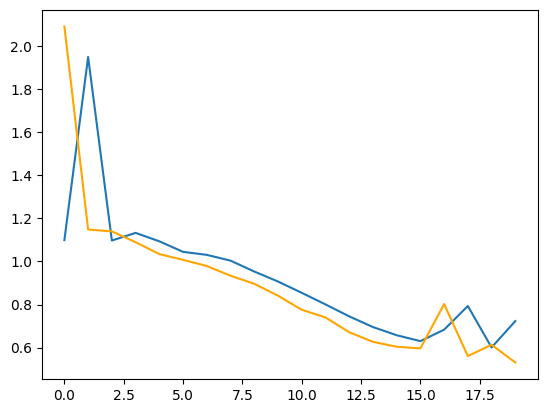

In [21]:
import matplotlib.pyplot as plt

plt.plot(range(len(l)), l,)
plt.plot(range(len(vl)), vl, color='orange')
plt.show()

In [22]:
from sklearn.metrics import accuracy_score

model.eval()
with torch.no_grad():
  test_outputs = model(test_features.unsqueeze(1).float())
  _, predicted = torch.max(test_outputs, 1)
  accuracy = accuracy_score(test_labels.numpy(), predicted.numpy())

print(f"Test Accuracy: {accuracy*100:.2f}%")

Test Accuracy: 72.00%


Things to change
- epochs
- number of data points
- number of languages
- other feature representations (hubert, waveLM)
- last_layer or mid_layer